In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
class Model(nn.Module): #classmodel that inherits the module nn
  #4 features of flower
  #-->> hidden layer h1
  #--> hidden layer h2
  #-->output 3 classes of output flowers
  def __init__(self,in_features=4,h1=8,h2=9,out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features,h1)
    self.fc2 = nn.Linear(h1,h2)
    self.out = nn.Linear(h2,out_features)
  def forward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x

In [3]:
torch.manual_seed(67) #randomseed
model = Model()

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [5]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
#last column string to int
my_df['variety'] = my_df['variety'].replace('Setosa',0)
my_df['variety'] = my_df['variety'].replace('Versicolor',1)
my_df['variety'] = my_df['variety'].replace('Virginica',2)

In [7]:
#trainsplit
X = my_df.drop('variety',axis=1)
y = my_df['variety']

#numpy array
X = X.values
y = y.values

from sklearn.model_selection import train_test_split

#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.2, random_state=41)
my_df


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [9]:
#64int = longtensor
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [10]:
#set criterion to measure error
criterion = nn.CrossEntropyLoss()
#Optimizer, learning rate (if no learning after few iterations (epochs))
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)


c:\Users\ROG ZEYPHRUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
#epochs
epochs = 100
losses =[]

for i in range(epochs):
    y_pred = model(X_train)# forward
    loss = criterion(y_pred, y_train)# loss

    optimizer.zero_grad()# zero grads
    loss.backward()# backprop
    optimizer.step()# update weights

    losses.append(loss.item())

    if i % 10 == 0:
        print(f"Epoch: {i}, Loss: {loss.item():3f}")

Epoch: 0, Loss: 1.081123
Epoch: 10, Loss: 0.941986
Epoch: 20, Loss: 0.762925
Epoch: 30, Loss: 0.538486
Epoch: 40, Loss: 0.371385
Epoch: 50, Loss: 0.257037
Epoch: 60, Loss: 0.155608
Epoch: 70, Loss: 0.087001
Epoch: 80, Loss: 0.051509
Epoch: 90, Loss: 0.033251


Text(0.5, 0, 'epochs')

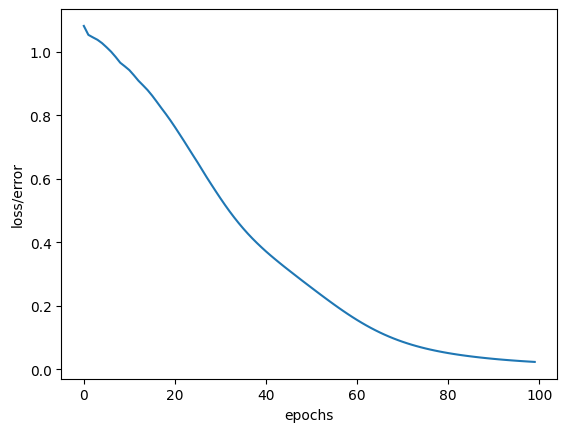

In [12]:
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel("epochs")